# Clustering

STEP 1: Loading and filtering data
Filtered shape: (3961, 15)
STEP 2: Engineering colony-level features
Colony-level dataset: 253 colonies

BEFORE scaling (sample):
   latitude  longitude  mean_count  std_count  trend_slope  year_span  num_surveys
0    -60.76     -44.64     2221.75     574.00        51.45         18            4
4    -71.31     170.20   327437.90  105371.68      7077.34         35           10
6    -62.41     -59.75     4518.00     809.15       -41.98         21            4
STEP 3: Scaling features (StandardScaler)
AFTER scaling (sample, first 3 rows):
   latitude  longitude  mean_count  std_count  trend_slope  year_span  num_surveys
0     1.107     -0.296      -0.226     -0.268       -0.019     -1.112       -0.677
1    -1.581      2.259      11.516     10.729       11.083      0.083       -0.213
2     0.688     -0.476      -0.143     -0.244       -0.167     -0.901       -0.677
STEP 4: Elbow method + Silhouette analysis
  k=2  Inertia=1233.3  Silhouette=0.8315  DB Ind

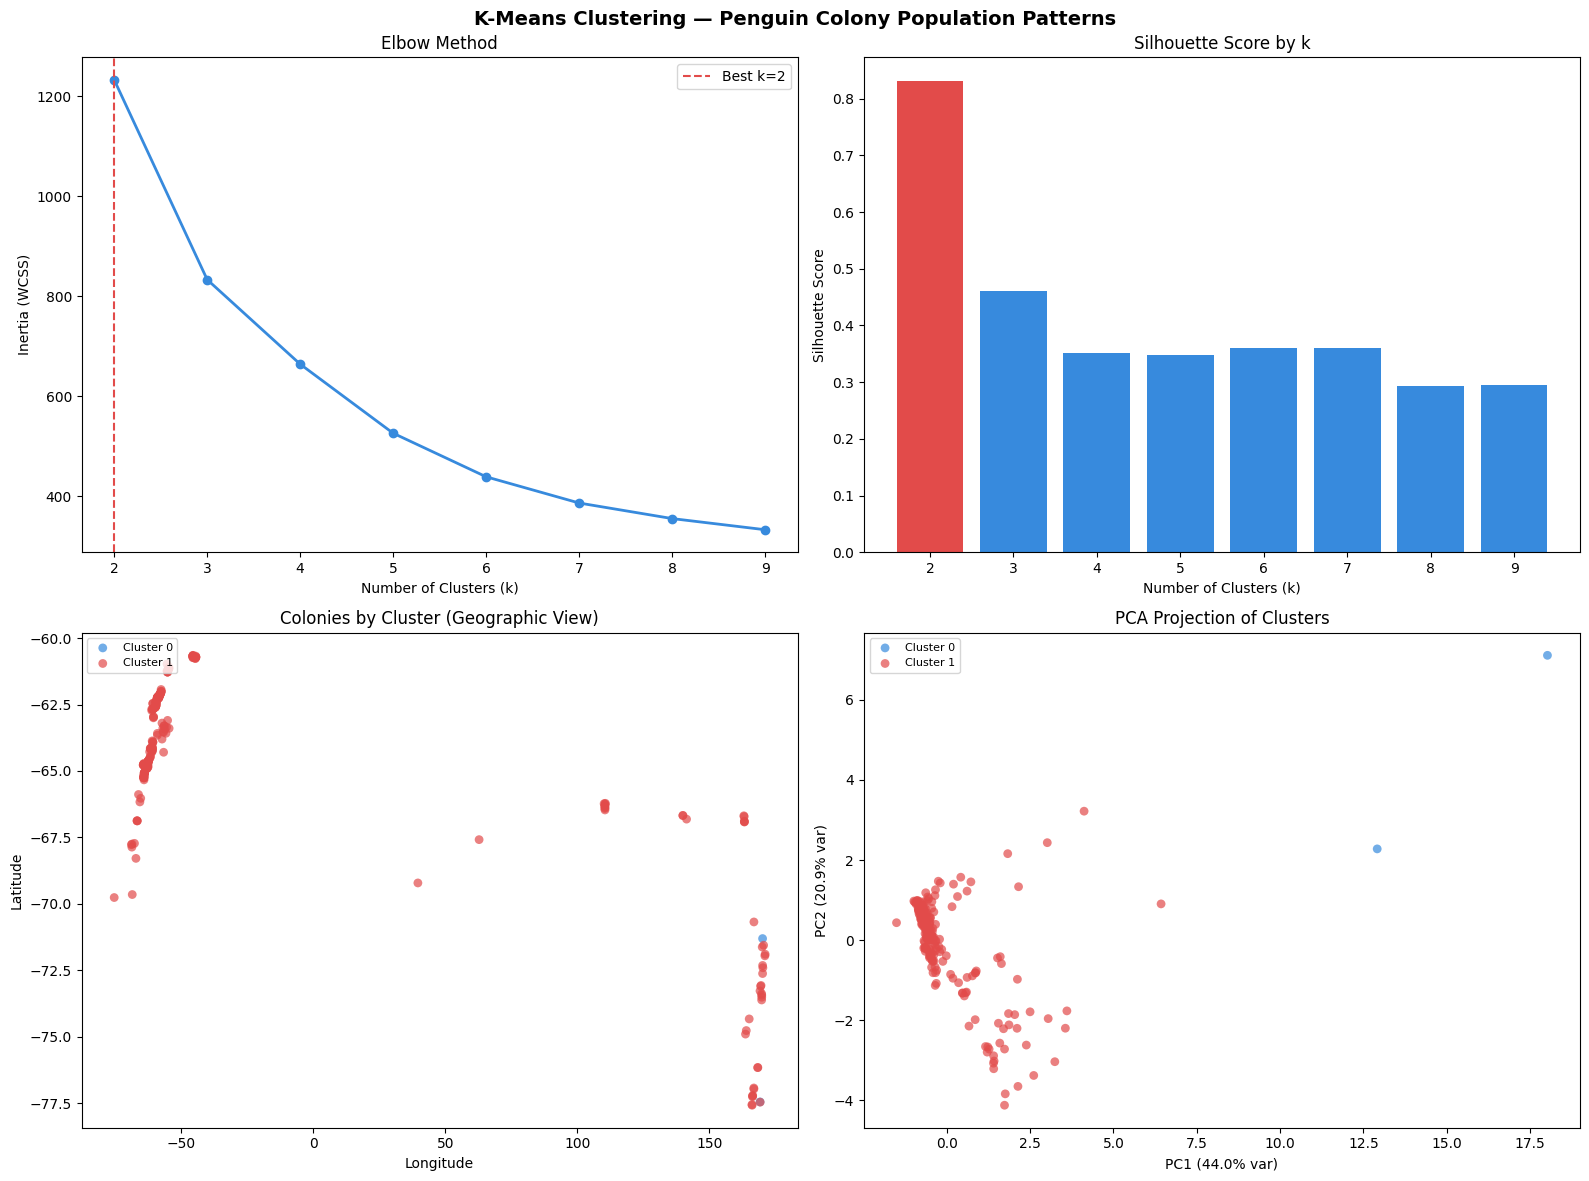


Saved: clustering_results.png
CLUSTER PROFILE INTERPRETATION
         num_colonies  avg_latitude  avg_longitude  avg_count  avg_slope
cluster                                                                 
0                   2        -74.38         169.72  250219.16    6333.28
1                 251        -65.03         -21.28    6550.85      13.45

Positive avg_slope = Growing trend. Negative = Declining.


In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings("ignore")

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA


print("STEP 1: Loading and filtering data")


df = pd.read_csv("DownloadAll.csv")
df = df[df["count_type"] == "nests"].dropna(subset=["penguin_count"])
print(f"Filtered shape: {df.shape}")


print("STEP 2: Engineering colony-level features")


def compute_slope(group):
    if len(group) < 3 or group["year"].max() == group["year"].min():
        return np.nan
    slope = np.polyfit(group["year"].values, group["penguin_count"].values, 1)[0]
    return slope

slopes = (
    df.groupby(["site_id", "common_name"])
    .apply(compute_slope)
    .reset_index()
    .rename(columns={0: "trend_slope"})
)

colony_df = df.groupby(["site_id", "common_name"]).agg(
    latitude=("latitude_epsg_4326", "first"),
    longitude=("longitude_epsg_4326", "first"),
    mean_count=("penguin_count", "mean"),
    std_count=("penguin_count", "std"),
    max_count=("penguin_count", "max"),
    year_span=("year", lambda x: x.max() - x.min()),
    num_surveys=("penguin_count", "count"),
).reset_index()

colony_df = colony_df.merge(slopes, on=["site_id", "common_name"])
colony_df = colony_df.dropna()
colony_df["std_count"] = colony_df["std_count"].fillna(0)
print(f"Colony-level dataset: {colony_df.shape[0]} colonies")

CLUSTER_FEATURES = [
    "latitude", "longitude", "mean_count",
    "std_count", "trend_slope", "year_span", "num_surveys"
]

print("\nBEFORE scaling (sample):")
print(colony_df[CLUSTER_FEATURES].head(3).round(2).to_string())


print("STEP 3: Scaling features (StandardScaler)")


scaler = StandardScaler()
X_scaled = scaler.fit_transform(colony_df[CLUSTER_FEATURES])

print("AFTER scaling (sample, first 3 rows):")
print(pd.DataFrame(X_scaled[:3], columns=CLUSTER_FEATURES).round(3).to_string())


print("STEP 4: Elbow method + Silhouette analysis")


inertias = []
silhouettes = []
db_scores = []
K_range = range(2, 10)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))
    db_scores.append(davies_bouldin_score(X_scaled, labels))
    print(f"  k={k}  Inertia={km.inertia_:.1f}  Silhouette={silhouettes[-1]:.4f}  DB Index={db_scores[-1]:.4f}")

# Best k by silhouette
best_k = K_range[np.argmax(silhouettes)]
print(f"\nOptimal k (highest silhouette): {best_k}")


print(f"STEP 5: Fitting K-Means with k={best_k}")


kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
colony_df["cluster"] = kmeans.fit_predict(X_scaled)

sil = silhouette_score(X_scaled, colony_df["cluster"])
db = davies_bouldin_score(X_scaled, colony_df["cluster"])
print(f"Final Silhouette Score:       {sil:.4f}  (closer to 1 = better)")
print(f"Final Davies-Bouldin Index:   {db:.4f}  (closer to 0 = better)")

print("\nCluster summary:")
summary = colony_df.groupby("cluster")[CLUSTER_FEATURES + ["cluster"]].mean().round(2)
print(summary.to_string())

#visualizations
colors = ["#378ADD", "#E24B4A", "#3B6D11", "#BA7517", "#7F77DD", "#D4537E", "#1D9E75", "#D85A30"]
cluster_colors = [colors[i % len(colors)] for i in range(best_k)]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("K-Means Clustering — Penguin Colony Population Patterns", fontsize=14, fontweight="bold")

# (a) Elbow curve
ax = axes[0, 0]
ax.plot(list(K_range), inertias, "o-", color="#378ADD", linewidth=2)
ax.axvline(best_k, color="#E24B4A", linestyle="--", label=f"Best k={best_k}")
ax.set_xlabel("Number of Clusters (k)")
ax.set_ylabel("Inertia (WCSS)")
ax.set_title("Elbow Method")
ax.legend()

# (b) Silhouette scores
ax = axes[0, 1]
ax.bar(list(K_range), silhouettes, color=[
    "#378ADD" if k != best_k else "#E24B4A" for k in K_range
])
ax.set_xlabel("Number of Clusters (k)")
ax.set_ylabel("Silhouette Score")
ax.set_title("Silhouette Score by k")

# (c) Geographic map of clusters
ax = axes[1, 0]
for cluster_id in range(best_k):
    mask = colony_df["cluster"] == cluster_id
    ax.scatter(
        colony_df.loc[mask, "longitude"],
        colony_df.loc[mask, "latitude"],
        c=cluster_colors[cluster_id],
        label=f"Cluster {cluster_id}",
        alpha=0.7, s=40, edgecolors="none"
    )
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Colonies by Cluster (Geographic View)")
ax.legend(loc="upper left", fontsize=8)

# (d) PCA 2D projection
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
ax = axes[1, 1]
for cluster_id in range(best_k):
    mask = colony_df["cluster"] == cluster_id
    ax.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        c=cluster_colors[cluster_id],
        label=f"Cluster {cluster_id}",
        alpha=0.7, s=40, edgecolors="none"
    )
var_explained = pca.explained_variance_ratio_ * 100
ax.set_xlabel(f"PC1 ({var_explained[0]:.1f}% var)")
ax.set_ylabel(f"PC2 ({var_explained[1]:.1f}% var)")
ax.set_title("PCA Projection of Clusters")
ax.legend(loc="upper left", fontsize=8)

plt.tight_layout()
plt.savefig("clustering_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nSaved: clustering_results.png")


print("CLUSTER PROFILE INTERPRETATION")

profile = colony_df.groupby("cluster").agg(
    num_colonies=("site_id", "count"),
    avg_latitude=("latitude", "mean"),
    avg_longitude=("longitude", "mean"),
    avg_count=("mean_count", "mean"),
    avg_slope=("trend_slope", "mean"),
).round(2)
print(profile.to_string())
print("\nPositive avg_slope = Growing trend. Negative = Declining.")